In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_aws import ChatBedrockConverse
llm = ChatBedrockConverse(
                            model_id="openai.gpt-oss-120b-1:0",
                            region_name= "us-east-1"
                        )

d:\Agentic AI\HR_Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
GITHUB_TOKEN=os.getenv("GITHUB_TOKEN")
HEADERS = {
    "Accept": "application/vnd.github+json",
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "X-GitHub-Api-Version": "2022-11-28"
}
GITHUB_API = "https://api.github.com"

In [3]:
from typing import TypedDict, Annotated,Optional,Literal
from typing import List, Dict
from pydantic import BaseModel, Field

def merge_summaries(existing: dict, new: list) -> dict:
    """Merge worker summaries from parallel branches into one dict."""
    result = dict(existing or {})
    for item in (new or []):
        result.update(item)
    return result

class GraphState(TypedDict):
    job_description: str
    url:str
    role_title: str
    applied_role: str
    routed_files: List[str]
    summaries: Annotated[dict, merge_summaries]
    next_action: str 
    total_files_found: int
    total_files_analysed: int
    repos_skipped: List[str]
    analyzed_repos: List[str]
    final_summary:str
    final_profile:str  
    github_score: int
    github_analysis: str 
    # resume fields
    resume_path:      str           # path to uploaded resume file
    resume_text:      str           # extracted text
    resume_score:     float
    resume_analysis:  str
    
    # extracted URLs — shared across nodes
    github_url:       Optional[str]
    linkedin_url:     Optional[str]
    candidate_email:  Optional[str]
    candidate_name:   Optional[str]
    # Decision
    decision:           Literal["auto_select", "auto_reject", "hitl", "no_github"]
    hitl_outcome:       Optional[Literal["approved", "rejected"]]
    hitl_reason:        Optional[str]
    hitl_packet:        Optional[dict]   # what HR sees
    rejection_reason:   str
    next_steps:         str
    email_sent:         bool
    


class ResumeScoreOutput(BaseModel):
    candidate_name:       str         = Field(description="Full name of the candidate extracted from resume")
    detected_seniority:   str         = Field(description="junior|mid|senior|founding")
    score:                int          = Field(description="0-100")
    matched_skills:       List[str]   = Field(default_factory=list)
    missing_skills:       List[str]   = Field(default_factory=list)
    nice_to_have_matched: List[str]   = Field(default_factory=list)
    seniority_alignment:  str         = Field(description="strong|partial|mismatch")
    domain_alignment:     str         = Field(description="strong|partial|mismatch")
    summary:              str         = Field(description="2-3 sentence assessment")

class GitHubScoreOutput(BaseModel):
    detected_seniority:  str         = Field(description="junior|mid|senior|founding")
    score:               int          = Field(description="0-100")
    relevant_projects:   List[str]   = Field(default_factory=list)
    originality_signal:  str         = Field(description="high|medium|low")
    summary:             str         = Field(description="2-3 sentence assessment")

class SynthesizerOutput(BaseModel):
    technical_stack:      str = Field(description="Languages, frameworks, tools used")
    project_highlights:   str = Field(description="Key projects and what they demonstrate")
    engineering_practices: str = Field(description="Code quality, testing, CI/CD, deployment patterns")
    strengths:            str = Field(description="Strongest technical signals observed")
    concerns:             str = Field(description="Gaps, red flags, or weak areas")
    overall_profile:      str = Field(description="2-3 sentence overall technical summary")

class FinalReviewOutput(BaseModel):
    candidate_summary:    str = Field(description="Who this candidate is technically")
    role_fit_assessment:  str = Field(description="How well they fit the specific JD")
    key_evidence:         str = Field(description="Concrete evidence from GitHub supporting the assessment")
    recommendation:       str = Field(description="Clear recommendation for decision engine")

class ResumeExtractorOutput(BaseModel):
    candidate_name:  str = Field(description="Full name of the candidate")
    candidate_email: str = Field(description="Email address or empty string")
    github_url:      str = Field(description="GitHub profile URL or empty string")
    linkedin_url:    str = Field(description="LinkedIn profile URL or empty string")
    role_title:      str = Field(description=(
        "The most recent or target job title of the candidate. "
        "Infer from their experience or objective section. "
        "Examples: 'Junior AI Engineer', 'Data Analyst', 'Senior ML Engineer'"
    ))

In [4]:
def normalize_url(url):
    url = url.replace("http://www.", "https://www.")
    url = url.replace("http://linkedin.com", "https://www.linkedin.com")
    url = url.replace("https://linkedin.com", "https://www.linkedin.com")
    url = url.replace("http://github.com", "https://github.com")
    return url.rstrip("/") 


In [5]:
from docx import Document
import re
import pdfplumber

def _extract_from_docx(docx_path: str) -> dict:
    doc = Document(docx_path)
    
    # extract full text
    text = "\n".join([para.text for para in doc.paragraphs])
    
    # extract hyperlinks from relationship XML
    # docx stores hyperlinks in word/_rels/document.xml.rels
    links = []
    for rel in doc.part.rels.values():
        if "hyperlink" in rel.reltype:
            links.append(rel.target_ref)
    
    # also scan text for plain URLs
    # plain text URL fallbacks
    plain_urls     = re.findall(r'https?://[^\s)>\"\n]+', text)
    github_plain   = re.findall(r'(?<!https://)(?<!http://)github\.com/[A-Za-z0-9_\-]+', text)
    linkedin_plain = re.findall(r'(?<!https://)(?<!http://)(?<!https://www\.)linkedin\.com/in/[A-Za-z0-9_\-]+', text)

    # broader email regex — catches any valid email in plain text
    email_plain    = re.findall(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', text)

    links.extend(plain_urls)

    # only add https:// prefix if not already captured as full URL
    for g in github_plain:
        full = "https://" + g
        if full not in links:
            links.append(full)

    for l in linkedin_plain:
        full = "https://www." + l
        if full not in links and "https://" + l not in links:
            links.append(full)

    # emails stored separately, not in links list
    emails_found = email_plain

    # deduplicate links
    seen = set()
    unique_links = []
    for l in links:
        # normalize linkedin — prefer www version
        normalized = normalize_url(l)
        if normalized not in seen:
            seen.add(normalized)
            unique_links.append(normalized)

    # classify
    github_url   = next((l for l in unique_links if "github.com"   in l), None)
    linkedin_url = next((l for l in unique_links if "linkedin.com" in l), None)

    # email — prefer annotation mailto, fallback to plain text
    email = next(
        (l.replace("mailto:", "") for l in unique_links if l.startswith("mailto:")),
        emails_found[0] if emails_found else None
    )

    return {
        "text":         text,
        "github_url":   github_url,
        "linkedin_url": linkedin_url,
        "email":        email,
        "all_links":    unique_links
    }

def _extract_from_pdf(pdf_path: str) -> dict:
    text  = ""
    links = []
    
    # text extraction + annotation layer via pdfplumber
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
            if page.annots:
                for annot in page.annots:
                    uri = annot.get("uri")
                    if uri:
                        links.append(uri)
    
    # annotation layer via pymupdf (more reliable for hyperlinks)
    try:
        import pymupdf
        doc = pymupdf.open(pdf_path)
        for page in doc:
            for link in page.get_links():
                uri = link.get("uri", "")
                if uri:
                    links.append(uri)
        doc.close()
    except ImportError:
        pass
    
    # plain text URL fallbacks
    plain_urls     = re.findall(r'https?://[^\s)>\"\n]+', text)
    github_plain   = re.findall(r'(?<!https://)(?<!http://)github\.com/[A-Za-z0-9_\-]+', text)
    linkedin_plain = re.findall(r'(?<!https://)(?<!http://)(?<!https://www\.)linkedin\.com/in/[A-Za-z0-9_\-]+', text)

    # broader email regex — catches any valid email in plain text
    email_plain    = re.findall(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', text)

    links.extend(plain_urls)

    # only add https:// prefix if not already captured as full URL
    for g in github_plain:
        full = "https://" + g
        if full not in links:
            links.append(full)

    for l in linkedin_plain:
        full = "https://www." + l
        if full not in links and "https://" + l not in links:
            links.append(full)

    # emails stored separately, not in links list
    emails_found = email_plain

    # deduplicate links
    seen = set()
    unique_links = []
    for l in links:
        normalized = normalize_url(l)
        if normalized not in seen:
            seen.add(normalized)
            unique_links.append(normalized)

    # classify
    github_url   = next((l for l in unique_links if "github.com"   in l), None)
    linkedin_url = next((l for l in unique_links if "linkedin.com" in l), None)

    # email — prefer annotation mailto, fallback to plain text
    email = next(
        (l.replace("mailto:", "") for l in unique_links if l.startswith("mailto:")),
        emails_found[0] if emails_found else None
    )

    return {
        "text":         text,
        "github_url":   github_url,
        "linkedin_url": linkedin_url,
        "email":        email,
        "all_links":    unique_links
    }

In [6]:

def resume_extractor(state: GraphState) -> dict:
    print("---RESUME EXTRACTOR---")
    path = state.get("resume_path", "")
    
    if not path:
        return {
            "resume_text":     "",
            "github_url":      state.get("github_url"),
            "linkedin_url":    state.get("linkedin_url"),
            "candidate_email": state.get("candidate_email"),
            "candidate_name":  state.get("candidate_name"),
            "role_title":      state.get("role_title"),
        }
    
    data = _extract_from_docx(path) if path.endswith(".docx") \
           else _extract_from_pdf(path)
    
    # Use LLM to extract structured metadata from resume text
    prompt_text = f"""Extract the following information from this resume.
For github_url and linkedin_url, look for both hyperlinks and plain text URLs.
For role_title, infer from their most recent job title or career objective.

Resume text:
{data["text"][:2000]}
"""
    extractor_llm = llm.with_structured_output(ResumeExtractorOutput)

    try:
        extracted: ResumeExtractorOutput = extractor_llm.invoke(prompt_text)
        
        return {
            "resume_text":     data["text"],
            "github_url":      extracted.github_url   or data.get("github_url")   or state.get("github_url"),
            "linkedin_url":    extracted.linkedin_url or data.get("linkedin_url") or state.get("linkedin_url"),
            "candidate_email": extracted.candidate_email or data.get("email")     or state.get("candidate_email"),
            "candidate_name":  extracted.candidate_name  or state.get("candidate_name"),
            "role_title":      extracted.role_title       or state.get("role_title", ""),
        }
        
    except Exception as e:
        print(f"  [resume_extractor structured output failed: {e}]")
        # fallback to regex extracted values
        return {
            "resume_text":     data["text"],
            "github_url":      data.get("github_url")   or state.get("github_url"),
            "linkedin_url":    data.get("linkedin_url") or state.get("linkedin_url"),
            "candidate_email": data.get("email")        or state.get("candidate_email"),
            "candidate_name":  state.get("candidate_name", ""),
            "role_title":      state.get("role_title", ""),
        }

In [7]:
RESUME_SCORER_PROMPT = """
You are an expert Technical Recruiter performing semantic resume screening.

Your job is to evaluate how well a candidate's resume matches a Job Description.
This is SEMANTIC matching — not keyword matching.

Examples of semantic matches:
- Resume says "LangGraph state machines" → JD says "agentic workflows" → MATCH
- Resume says "FAISS vector store" → JD says "vector databases" → MATCH  
- Resume says "AWS Lambda" → JD says "cloud deployment" → MATCH
- Resume says "Power BI dashboards" → JD says "AI Engineer" → NOT RELEVANT

FIRST — identify the seniority level from the JD:
- JUNIOR (0-2 years): demos and learning projects are expected, not penalized
- MID (2-4 years): mix of projects and some real-world experience expected
- SENIOR (4+ years): production systems and architecture decisions expected
- FOUNDING/STAFF: proven track record of shipping at scale expected

Scoring rubric (0-100) applied RELATIVE to detected seniority:
90-100 : Exceptional match — candidate exceeds expectations for this level
70-89  : Strong match — candidate meets most requirements for this level
50-69  : Moderate match — some alignment but notable gaps
30-49  : Weak match — significant gaps for this level
0-29   : Poor match — misaligned role or level

Evaluate these dimensions:
1. Must-have skills coverage — how many required skills are present (semantically)
2. Nice-to-have coverage — bonus skills present
3. Seniority alignment — does experience level match the role
4. Domain alignment — does candidate background fit the industry/domain
5. Education relevance — is the degree/certification relevant

CRITICAL: Return ONLY structured output. No explanations. No tags.

"""


In [8]:


def resume_scorer(state: GraphState) -> dict:
    print("--- RESUME SCORER ---")

    resume_text = state.get("resume_text", "")
    jd          = state.get("job_description", "")

    if not resume_text:
        return {"resume_score": 0.0, "resume_analysis": "No resume text available."}
    if not jd:
        return {"resume_score": 0.0, "resume_analysis": "No job description provided."}

    prompt_text = f"""{RESUME_SCORER_PROMPT}

Job Description:
{jd}

Candidate Resume:
{resume_text}
"""
    resume_llm = llm.with_structured_output(ResumeScoreOutput)

    try:
        data: ResumeScoreOutput = resume_llm.invoke(prompt_text)

        analysis = (
            f"Candiate Name      : {data.candidate_name}\n"
            f"Detected Seniority : {data.detected_seniority}\n"
            f"Score              : {data.score}/100\n"
            f"Seniority Alignment: {data.seniority_alignment}\n"
            f"Domain Alignment   : {data.domain_alignment}\n\n"
            f"Matched Skills     : {', '.join(data.matched_skills)}\n"
            f"Missing Skills     : {', '.join(data.missing_skills)}\n"
            f"Nice-to-Have Found : {', '.join(data.nice_to_have_matched)}\n\n"
            f"Summary: {data.summary}"
        )

        return {
            "resume_score":    float(data.score),
            "resume_analysis": analysis,
            "candidate_name":  data.candidate_name or state.get("candidate_name", "")
        }
        

    except Exception as e:
        print(f"  [resume_scorer structured output failed: {e}]")
        # fallback — plain llm call, extract score from text
        response = llm.invoke(prompt_text)
        return {
            "resume_score":    0,
            "resume_analysis": response.content,
        }

In [9]:
import re, json

def safe_parse_json(raw: str, fallback: dict) -> dict:
    raw = re.sub(r"```json|```", "", raw).strip()
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if match:
        raw = match.group(0)
    raw = re.sub(r",\s*([}\]])", r"\1", raw)
    try:
        return json.loads(raw)
    except Exception:
        return fallback

In [10]:
from urllib.parse import urlparse

def extract_github_username(github_url: str) -> str:
    path = urlparse(github_url).path.strip("/")
    return path.split("/")[0]

In [11]:
import requests
def get_all_repos(username: str) -> list:
    repos = []
    page = 1

    while True:
        url = f"{GITHUB_API}/users/{username}/repos"
        params = {"per_page": 100, "page": page}
        resp = requests.get(url, headers=HEADERS,params=params, timeout=15)

        if resp.status_code != 200:
            break

        batch = resp.json()
        if not batch:
            break
                # Only keep repos the candidate actually owns
        # Filter out forks, empty repos, and archived repos
        filtered = [
            r for r in batch
            if not r.get("fork", False)           # exclude forks
            and not r.get("archived", False)       # exclude archived
            and r.get("size", 0) > 0              # exclude empty repos
        ]

        repos.extend(filtered)
        page += 1

    return repos

In [12]:

RELEVANT_EXTENSIONS = {
    ".py", ".ipynb", ".md", ".yml", ".yaml", 
    "dockerfile", ".env", ".cfg", ".ini"
}

SKIP_DIRS = {
    "node_modules", ".git", "__pycache__", ".venv", "venv",
    "env", "dist", "build", ".idea", ".vscode", "vendor",
    "assets", "images", "img", "static", "media", "fonts"
}
MAX_FILES_PER_WORKER = 50

def traverse_repo(owner, repo, path=""):
    url = f"{GITHUB_API}/repos/{owner}/{repo}/contents/{path}"
    res = requests.get(url, headers=HEADERS, timeout=15)
    
    if res.status_code != 200:
        return

    for item in res.json():
        if item["type"] == "file":
            filename = item["name"].lower()
            # Check if extension is relevant before yielding
            ext = os.path.splitext(filename)[1]
            if ext in RELEVANT_EXTENSIONS or filename in ("dockerfile", "makefile"):
                yield item
        elif item["type"] == "dir":
            # Skip irrelevant directories entirely
            if item["name"].lower() not in SKIP_DIRS:
                yield from traverse_repo(owner, repo, item["path"])



In [13]:
MAX_FILES_PER_REPO = 100
MAX_TOTAL_FILES = 500

def profile_extractor(state: GraphState):
    print("---PROFILE EXTRACTOR---")
    urls = []
    skipped_repos = []
    analyzed_repos = []
    total_found = 0

    user_name = extract_github_username(state["github_url"])
    try:
        repos = get_all_repos(user_name)
    except Exception as e:
        print(f"error occured with github :{e}")
        return

    print(f"  Found {len(repos)} original repos (forks excluded)")

    for repo in repos:
        if len(urls) >= MAX_TOTAL_FILES:
            print(f"  Total cap reached, stopping.")
            break
        try:
            repo_count = 0
            for file in traverse_repo(user_name, repo["name"]):
                if file.get("download_url"):
                    urls.append(file["download_url"])
                    repo_count += 1
                    total_found += 1
                    if repo_count >= MAX_FILES_PER_REPO:
                        break
            if repo_count > 0:
                analyzed_repos.append(repo["name"])
        except Exception as e:
            skipped_repos.append(repo["name"])
            continue

    print(f"  Analyzed repos: {analyzed_repos}")
    print(f"  Found {len(urls)} relevant files")

    return {
        "routed_files":          urls,
        "total_files_found":     total_found,
        "total_files_analyzed":  len(analyzed_repos),
        "repos_skipped":         skipped_repos,
        "analyzed_repos":        analyzed_repos,
    
    }

In [14]:
def supervisor(state:GraphState):
    """
    Supervisor decides which worker runs next
    or whether to move to the synthesizer.
    """
    print("---SUPERVISOR---")

    worker_order = [
        "python_worker",
        "readme_worker",
        "infra_worker",
        "config_worker",
        "notebook_worker",
    ]

    summaries = state["summaries"]
    routed_files = state["routed_files"]

    for worker in worker_order:
        #files = routed_files.get(worker, [])
        summary_exists = worker in summaries

        if routed_files and not summary_exists:
            return {"next_action": worker}

    # All workers completed or had no files
    return {"next_action": "synthesizer"}

In [15]:
from langgraph.types import Send

MAX_FILES_PER_WORKER = 50  

def dispatch_workers(state: GraphState) -> list:
    print("--- DISPATCH WORKERS (parallel) ---")
    routed_files = state.get("routed_files", [])

    worker_extensions = {
        "python_worker":   (".py",),
        "readme_worker":   ("readme.md",),
        "infra_worker":    ("dockerfile", ".yml", ".yaml"),
        "config_worker":   (".env", ".cfg", ".ini"),
        "notebook_worker": (".ipynb",),
    }

    sends = []
    for worker, extensions in worker_extensions.items():
        matched = [u for u in routed_files if u.lower().endswith(extensions)]
        
        # Cap to avoid infinite runtimes
        if len(matched) > MAX_FILES_PER_WORKER:
            print(f"  Capping {worker}: {len(matched)} → {MAX_FILES_PER_WORKER} files")
            matched = matched[:MAX_FILES_PER_WORKER]

        if matched:
            print(f"  → dispatching {worker} ({len(matched)} files)")
            sends.append(Send(worker, {**state, "routed_files": matched}))

    if not sends:
        return [Send("synthesizer", state)]

    return sends

In [16]:
import requests

def fetch_file_content(url: str, timeout: int = 15) -> str:
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    return resp.text

In [17]:
from langchain_core.prompts import ChatPromptTemplate
python_worker_prompt=""" 
You are a Python Code Analysis Agent.

You have already been provided with Python source code extracted from GitHub repositories.

IMPORTANT:
- Do NOT ask for repositories or files.
- Do NOT request additional inputs.
- Analyze ONLY the code provided below.

Your task:
Extract engineering-relevant signals, focusing on:
- Code structure and organization
- Use of libraries and frameworks
- Error handling, modularity, and patterns
- Engineering maturity indicators

Rules:
- Do NOT infer infrastructure, databases, or frameworks unless explicitly imported or implemented.
- Do NOT assume scale, performance, or production usage.
- Avoid speculative language.

Output Format:
- Project Intent & Scope
- Technical Stack & Dependencies
- Code Structure & Design Patterns
- Quality & Maintainability Signals
- Notable Engineering Observations
- cloud platforms

"""

In [18]:
import json
def extract_notebook_code(ipynb_content: str) -> str:
    nb = json.loads(ipynb_content)
    code_cells = []

    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "code":
            source = "".join(cell.get("source", []))
            if source.strip():
                code_cells.append(source)

    return "\n\n".join(code_cells)

In [19]:
def generic_worker(state: GraphState, worker_key: str, system_prompt: str) -> dict:
    urls = state.get("routed_files", [])
    batch_size = 10  # increase batch size too
    batch_summaries = []

    for i in range(0, len(urls), batch_size):
        batch = urls[i:i + batch_size]
        code_blocks = []

        for url in batch:
            try:
                content = fetch_file_content(url)
                if worker_key == "notebook_worker":
                    content = extract_notebook_code(content)
                code_blocks.append(f"\n### File: {url}\n```\n{content}\n```")
            except Exception:
                continue

        if not code_blocks:
            continue

        prompt = ChatPromptTemplate.from_messages([
            ("system", system_prompt),
            ("human", "Analyze the following files:\n{code_blocks}"),
        ])
        response = llm.invoke(prompt.format(code_blocks="\n".join(code_blocks)))
        batch_summaries.append(response.content)

    if not batch_summaries:
        summary = f"No relevant files for {worker_key}."
    elif len(batch_summaries) == 1:
        # Only one batch — no need for extra LLM call
        summary = batch_summaries[0]
    else:
        # Multiple batches — consolidate into one summary
        consolidation_prompt = ChatPromptTemplate.from_messages([
            ("system", system_prompt),
            ("human", """You have analyzed files in multiple batches. 
            Here are the batch analyses:

            {batch_summaries}

            Consolidate these into a single coherent technical summary. 
            Remove duplication. Preserve all concrete technical evidence."""),
        ])
        final = llm.invoke(consolidation_prompt.format(
            batch_summaries="\n\n---\n\n".join(
                f"Batch {i+1}:\n{s}" for i, s in enumerate(batch_summaries)
            )
        ))
        summary = final.content

    print(f"Worker Name: {worker_key} has Finished")
    return {"summaries": [{worker_key: summary}]}

In [20]:
def python_worker(state:GraphState):
    print("---PYHTON_WORKER---")
    return generic_worker(
        state=state,
        worker_key="python_worker",
        system_prompt=python_worker_prompt,
    )

In [21]:
readme_worker_prompt=""" 
You are a Technical Documentation Analysis Agent.

You have already been provided with documentation content (README or markdown files)
extracted from GitHub repositories.

IMPORTANT:
- Do NOT request documentation or repositories.
- Analyze ONLY the content provided.

Your task:
Extract signals about:
- Project clarity and intent
- System understanding
- Communication quality
- Documentation completeness

Rules:
- Base conclusions only on written content.
- Do NOT assume undocumented features or systems.

Output Format:
- Project Purpose & Context
- Intended Usage & Scope
- Setup & Execution Clarity
- Architectural or Design Explanation
- Documentation Strengths & Gaps
"""

In [22]:
def readme_worker(state:GraphState):
        print("---README_WORKER---")
        return generic_worker(
        state=state,
        worker_key="readme_worker",
        system_prompt=readme_worker_prompt,
    )

In [23]:
infra_worker_prompt=""" 
You are an Infrastructure & DevOps Analysis Agent.

You have already been provided with infrastructure-related file contents
(Dockerfiles, YAML files, CI/CD configs, cloud configs).

IMPORTANT:
- Do NOT ask for infrastructure files.
- Analyze ONLY the content provided.

Your task:
Extract signals about:
- Deployment readiness
- Environment configuration
- Automation and DevOps practices

Rules:
- If infrastructure is minimal or absent, state that clearly.
- Do NOT infer cloud usage or orchestration unless explicitly defined.

Output Format:
- Infrastructure Components Identified
- Deployment & Environment Strategy
- Automation & CI/CD Signals
- Operational & Scalability Observations
- Infrastructure Maturity Signals

"""

In [24]:
def infra_worker(state:GraphState):
    print("---INFRA_WORKER---")
    return generic_worker(
        state=state,
        worker_key="infra_worker",
        system_prompt=infra_worker_prompt,
    )

In [25]:
config_worker_prompt=""" 
You are a Configuration & Integration Analysis Agent.

You have already been provided with configuration-related content
(.env patterns, config files, integration code and docker files).

IMPORTANT:
- Do NOT ask for additional configuration files.
- Analyze ONLY the provided content.

Your task:
Extract signals about:
- External dependencies
- Configuration management
- Integration patterns

Rules:
- Do NOT assume secret management or environments unless explicitly shown.

Output Format:
- Configuration Management Approach
- External Services & Integrations
- Flexibility & Extensibility Signals
- Observed Best Practices
- Configuration Design Observations


"""

In [26]:
def config_worker(state:GraphState):
       print("---CONFIG_WORKER---")
       return generic_worker(
        state=state,
        worker_key="config_worker",
        system_prompt=config_worker_prompt,
    )

In [27]:
notebook_worker_prompt=""" 
You are a Notebook & Experimentation Analysis Agent.

You have already been provided with the extracted SOURCE CODE from one or more
Jupyter notebooks. Output cells, execution results, and plots have already been removed.

IMPORTANT:
- Do NOT ask for notebooks or repositories.
- Do NOT request additional files.
- Analyze ONLY the content provided below.

Your task:
Analyze the notebook code to extract signals about:
- Experimentation style (exploratory, demo, tutorial, prototype)
- Problem-solving approach
- Analytical thinking and tooling usage

Rules:
- Treat notebooks as experimental by default.
- Do NOT assume production readiness.
- Do NOT infer results, performance, or correctness.
- Only state what is explicitly present.

Output Format:
- Notebook Objective
- Analytical or ML Workflow
- Experimentation & Reasoning Patterns
- Reproducibility & Structure Signals
- Observed Strengths & Gaps

"""

In [28]:
def notebook_worker(state:GraphState):
    print("---NOTEBOOK_WORKER---")
    return generic_worker(
        state=state,
        worker_key="notebook_worker",
        system_prompt=notebook_worker_prompt,
    )

In [29]:
synthesizer_prompt=""" 
You are a Technical Synthesis Agent.

You will be given multiple technical summaries produced by specialized analysis agents
(Python code, documentation, infrastructure, configuration, notebooks).

Your task is to synthesize these summaries into a single coherent technical profile.

Instructions:
- Identify recurring patterns across summaries
- Remove duplication and overlap
- Preserve concrete technical evidence
- Highlight strengths only if supported by multiple summaries
- Identify gaps only if consistently observed
- Do NOT introduce new tools, skills, or claims
- Do NOT rate the candidate or use seniority labels
- Do NOT rewrite worker outputs verbatim

CRITICAL: Return ONLY structured output. No explanations. No tags.


"""

In [30]:
def synthesizer(state: GraphState) -> dict:
    print("---SYNTHESIZER---")
    summaries_text = "\n\n".join(
        f"### {k.upper()}\n{v}" for k, v in state.get("summaries", {}).items()
    )
    
    # prepend repo list so github_scorer sees actual repo names
    repo_list = "\n".join(f"  - {r}" for r in state.get("analyzed_repos", []))
    prompt_text = f"""{synthesizer_prompt}

ANALYZED REPOSITORIES:
{repo_list}

WORKER SUMMARIES:
{summaries_text}
"""
    synthesizer_llm  = llm.with_structured_output(SynthesizerOutput)
    try:
        data: SynthesizerOutput = synthesizer_llm.invoke(prompt_text)
        
        final_profile = (
            f"TECHNICAL STACK:\n{data.technical_stack}\n\n"
            f"PROJECT HIGHLIGHTS:\n{data.project_highlights}\n\n"
            f"ENGINEERING PRACTICES:\n{data.engineering_practices}\n\n"
            f"STRENGTHS:\n{data.strengths}\n\n"
            f"CONCERNS:\n{data.concerns}\n\n"
            f"OVERALL PROFILE:\n{data.overall_profile}"
        )
        return {"final_profile": final_profile}
        
    except Exception as e:
        print(f"  [synthesizer structured output failed: {e}]")
        response = llm.invoke(prompt_text)
        return {"final_profile": (response)}



In [31]:
finali_review_prompt=""" 
You are a Final Technical Review Agent.

You will receive a synthesized technical profile of a software engineer based on
analysis of multiple GitHub repositories.

Your task is to produce a clear, professional, human-readable technical report.

Instructions:
- Preserve technical accuracy
- Avoid exaggeration or speculation
- Use neutral, professional language
- Avoid generic praise
- Avoid hiring decisions
- Avoid seniority labels
- Present observations as evidence-based statements

CRITICAL: Return ONLY structured output. No explanations. No tags.

"""

In [32]:
def final_review(state: GraphState) -> dict:
    print("---FINAL_REVIEW---")
    prompt_text = f"""{finali_review_prompt}

Job Description:
{state.get("job_description", "")}

GitHub Technical Profile:
{state.get("final_profile", "")}
"""
    final_review_llm = llm.with_structured_output(FinalReviewOutput)

    try:
        data: FinalReviewOutput = final_review_llm.invoke(prompt_text)
        
        final_summary = (
            f"CANDIDATE SUMMARY:\n{data.candidate_summary}\n\n"
            f"ROLE FIT ASSESSMENT:\n{data.role_fit_assessment}\n\n"
            f"KEY EVIDENCE:\n{data.key_evidence}\n\n"
            f"RECOMMENDATION:\n{data.recommendation}"
        )
        return {"final_summary": final_summary}
        
    except Exception as e:
        print(f"  [final_review structured output failed: {e}]")
        response = llm.invoke(prompt_text)
        return {"final_summary": (response)}

In [33]:
GITHUB_SCORER_PROMPT = """
You are an expert Technical Recruiter specializing in GitHub profile evaluation.

You will receive a Job Description and a structured GitHub technical profile.
Score how relevant and strong the candidate's GitHub work is for this specific role.

Scoring rubric (0-100):
90-100 : Highly aligned — strong, original, relevant projects with real depth
70-89  : Good alignment — relevant projects show genuine technical investment
50-69  : Moderate — some relevant work but mixed or shallow depth
30-49  : Weak — minimal activity or very little role alignment
0-29   : No meaningful GitHub presence or completely irrelevant projects

Also evaluate:
- Evidence of copied/forked projects with no original contributions
- Stale profiles (no recent commits)
- Mismatches between resume claims and actual GitHub evidence


CRITICAL: Return ONLY structured output. No explanations. No tags.

"""


In [34]:
# bind structured output to llm
github_llm = llm.with_structured_output(GitHubScoreOutput)

def github_scorer(state: GraphState) -> dict:
    print("--- GITHUB SCORER ---")

    profile = state.get("final_profile", "")
    jd      = state.get("job_description", "")

    # if not profile or len(profile.strip()) < 50:
    #     return {
    #         "github_score":    0.0,
    #         "github_analysis": "GitHub profile could not be analyzed."
    #     }
    
    analyzed = state.get("total_files_analyzed", 0)
    total    = state.get("total_files_found", 0)

    prompt_text = f"""{GITHUB_SCORER_PROMPT}

Job Description:
{jd}

Candidate GitHub Technical Profile:
{profile}

Analysis Coverage: ({analyzed} of {total} files analyzed)
"""

    try:
        data: GitHubScoreOutput = github_llm.invoke(prompt_text)

        analysis = (
            f"Detected Seniority : {data.detected_seniority}\n"
            f"Score              : {data.score}/100\n"
            f"Originality Signal : {data.originality_signal}\n\n"
            f"Relevant Projects  :\n"
            + "\n".join(f"  • {p}" for p in data.relevant_projects) +
            f"\n\nSummary: {data.summary}"
        )

        return {
            "github_score":    float(data.score),
            "github_analysis": analysis,
        }

    except Exception as e:
        print(f"  [github_scorer structured output failed: {e}]")
        # fallback
        response = llm.invoke(prompt_text)

        return {
            "github_score":    0,
            "github_analysis": response.content,
        }

In [35]:

SCORE_THRESHOLD = 70   # HR can adjust this

def route_decision(state: GraphState) -> str:
    """
    Simple routing based on single threshold.
    HR controls everything below threshold.
    """
    resume_score  = state.get("resume_score",  0.0)
    github_score  = state.get("github_score",  0.0)
    github_url    = state.get("github_url",    "")
    

    # No GitHub URL → HITL
    if not github_url:
        return "hitl"

    # GitHub unanalyzable (0 repos found) → HITL
    if github_score == 0.0 and github_url:
        return "hitl"

    # Both above threshold → auto select
    if resume_score >= SCORE_THRESHOLD and github_score >= SCORE_THRESHOLD:
        return "auto_select"

    # Everything else → HITL
    # HR decides: reject, approve, or request more info
    return "hitl"

In [36]:
def route_hitl_outcome(state: GraphState) -> str:
    """Routes after HR makes their decision."""
    return state.get("hitl_outcome", "rejected")

In [37]:
def _build_hitl_reason(
    resume_score, github_score,
    github_url
) -> str:
    """Builds a clear reason string for HR context."""


    if not github_url:
        return (
            f"No GitHub URL found in resume. "
            f"Resume score: {resume_score}/100. "
            f"Please request GitHub profile from candidate or review resume manually."
        )

    if github_score == 0.0 and github_url:
        return (
            f"GitHub URL provided ({github_url}) but profile could not be analyzed "
            f"(no public repositories found or URL may be incorrect). "
            f"Resume score: {resume_score}/100."
        )


    if resume_score < SCORE_THRESHOLD and github_score >= SCORE_THRESHOLD:
        return (
            f"GitHub score ({github_score}/100) is strong but resume score "
            f"({resume_score}/100) is below threshold ({SCORE_THRESHOLD}). "
            f"GitHub suggests strong capability — worth reviewing resume carefully."
        )

    if resume_score >= SCORE_THRESHOLD and github_score < SCORE_THRESHOLD:
        return (
            f"Resume score ({resume_score}/100) is strong but GitHub score "
            f"({github_score}/100) is below threshold ({SCORE_THRESHOLD}). "
            f"Please verify claimed skills against GitHub evidence."
        )

    return (
        f"Scores below threshold. "
        f"Resume: {resume_score}/100 | GitHub: {github_score}/100 | "
        f"Threshold: {SCORE_THRESHOLD}/100."
    )


def _build_hitl_packet(state: GraphState, hitl_reason: str) -> dict:
    """Builds the complete review packet HR sees."""
    

    packet = {
        # Candidate info
        "candidate_name":    state.get("candidate_name",  "N/A"),
        "candidate_email":   state.get("candidate_email", "N/A"),
        "applied_role":      state.get("applied_role", ""),
        "current_role":      state.get("role_title", ""),   
        "github_url":        state.get("github_url",      "N/A"),
        "linkedin_url":      state.get("linkedin_url",    "N/A"),

        # Scores
        "resume_score":      state.get("resume_score",  0.0),
        "github_score":      state.get("github_score",  0.0),
        "score_threshold":   SCORE_THRESHOLD,

        # Analysis
        "resume_analysis":   state.get("resume_analysis",  ""),
        "github_analysis":   state.get("github_analysis",  ""),
        "final_profile":     state.get("final_profile",    ""),

        # Coverage
        "files_analyzed":    state.get("total_files_analyzed", 0),
        "total_files":       state.get("total_files_found",    0),
        "analyzed_repos":    state.get("analyzed_repos",       []),


        # HR context
        "review_reason":     hitl_reason,
        "hr_actions":        ["approve", "reject", "request_more_info"],
        "instructions": (
            "Review the candidate profile and analysis below. "
            "Respond with your decision: approve, reject, or request_more_info."
        ),
    }

    # Add warnings if needed
    warnings = []

    if not state.get("github_url"):
        warnings.append(
            "⚠️ NO GITHUB: No GitHub profile available for this candidate."
        )

    packet["warnings"] = warnings
    return packet



In [38]:
def decision_engine(state: GraphState) -> dict:
    print("--- DECISION ENGINE ---")

    resume_score = state.get("resume_score",  0.0)
    github_score = state.get("github_score",  0.0)
    github_url   = state.get("github_url",    "")
    role         = state.get("applied_role",    "the position")
 

    # Determine routing
    decision = route_decision(state)

    # Build HITL reason for HR context
    hitl_reason = _build_hitl_reason(
        resume_score, github_score,
        github_url
    )

    # Build HR review packet — only for HITL cases
    hitl_packet = None
    if decision == "hitl":
        hitl_packet = _build_hitl_packet(state, hitl_reason)

    # Build next_steps for auto_select
    next_steps = ""
    if decision == "auto_select":
        next_steps = (
            f"Congratulations! We are pleased to invite you to the next stage "
            f"of the interview process for the {role} position. "
            f"Our team will be in touch within 2 business days to schedule "
            f"a technical interview."
        )

    print(f"  Decision: {decision.upper()} "
          f"(Resume: {resume_score}, GitHub: {github_score})")

    return {
        "decision":      decision,
        "hitl_reason":   hitl_reason,
        "hitl_packet":   hitl_packet,
        "next_steps":    next_steps,
        "rejection_reason": "",
    }



In [39]:
def _parse_hr_response(human_response) -> tuple:
    """Parses HR response — handles both dict and string formats."""
    import json, re

    try:
        if isinstance(human_response, dict):
            outcome = human_response.get("outcome", "rejected")
            reason  = human_response.get("reason",  "Decision made by HR team.")
            return outcome, reason

        if isinstance(human_response, str):
            # try JSON parse
            cleaned = re.sub(r"```json|```", "", human_response).strip()
            match   = re.search(r"\{.*\}", cleaned, re.DOTALL)
            if match:
                data    = json.loads(match.group(0))
                outcome = data.get("outcome", "rejected")
                reason  = data.get("reason",  "Decision made by HR team.")
                return outcome, reason

            # fallback — plain text response
            text = human_response.lower().strip()
            if "approve" in text:
                return "approved", human_response
            elif "more info" in text or "request" in text:
                return "request_more_info", human_response
            else:
                return "rejected", human_response

    except Exception:
        pass

    return "rejected", str(human_response)




In [40]:
from langgraph.types import interrupt

def hitl_node(state: GraphState) -> dict:
    print("--- HITL: Awaiting HR Decision ---")

    packet = state.get("hitl_packet", {})

    # Print review packet to console (for notebook testing)
    print("\n" + "="*60)
    print("HR REVIEW PACKET")
    print("="*60)
    print(f"Candidate     : {packet.get('candidate_name')}")
    print(f"Role          : {packet.get('applied_role')}")
    print(f"Resume Score  : {packet.get('resume_score')}/100")
    print(f"GitHub Score  : {packet.get('github_score')}/100")
    print(f"GitHub URL    : {packet.get('github_url')}")
    if packet.get("warnings"):
        print("\nWarnings:")
        for w in packet["warnings"]:
            print(f"  {w}")
    print(f"\nReason for review: {packet.get('review_reason')}")
    print("="*60)
    print("\nResume Analysis:")
    print(packet.get("resume_analysis", "N/A"))
    print("\nGitHub Analysis:")
    print(packet.get("github_analysis", "N/A"))
    print("="*60 + "\n")

    # Interrupt graph — waits for HR input
    # HR responds with: {"outcome": "approved"|"rejected"|"request_more_info", "reason": "..."}
    human_response = interrupt({
        "type":          "hr_review",
        "review_packet": packet,
        "instructions":  (
            'Provide your decision as: '
            '{"outcome": "approved" | "rejected" | "request_more_info", '
            '"reason": "your notes here"}'
        ),
    })

    # Parse HR response
    outcome, reason = _parse_hr_response(human_response)

    print(f"--- HR DECISION: {outcome.upper()} ---")
    print(f"    Reason: {reason}")

    role = state.get("applied_role", "the position")

    if outcome == "approved":
        return {
            "hitl_outcome": "approved",
            "hitl_reason":  reason,
            "next_steps": (
                f"Congratulations! Following a thorough review of your profile, "
                f"we are pleased to invite you to the next stage of the interview "
                f"process for the {role} position. "
                f"Our team will be in touch within 2 business days.\n\n"
                f"Reviewer note: {reason}"
            ),
            "rejection_reason": "",
        }

    elif outcome == "request_more_info":
        return {
            "hitl_outcome": "rejected",   # treated as soft reject for email routing
            "hitl_reason":  reason,
            "next_steps":   "",
            "rejection_reason": (
                f"Thank you for your interest in the {role} position at our company. "
                f"After reviewing your application, we would like to request some "
                f"additional information before proceeding.\n\n"
                f"{reason}\n\n"
                f"Please reply to this email with the requested information."
            ),
        }

    else:  # rejected
        return {
            "hitl_outcome": "rejected",
            "hitl_reason":  reason,
            "next_steps":   "",
            "rejection_reason": (
                f"Thank you for your interest in the {role} position. "
                f"After a careful review of your application and profile, "
                f"we regret to inform you that we will not be moving forward "
                f"with your application at this time.\n\n"
                f"We appreciate the time you invested in applying and wish you "
                f"the very best in your search."
            ),
        }



In [41]:

import os, smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def _send_email(to_email: str, subject: str, body: str):
    smtp_user = os.getenv("SMTP_USER",     "")
    smtp_pass = os.getenv("SMTP_PASSWORD", "")
    smtp_host = os.getenv("SMTP_HOST",     "smtp.gmail.com")
    smtp_port = int(os.getenv("SMTP_PORT", "587"))

    if not smtp_user or not smtp_pass:
        # Print email to console if no SMTP configured
        print(f"\n{'='*60}")
        print(f"[EMAIL PREVIEW — no SMTP configured]")
        print(f"To      : {to_email}")
        print(f"Subject : {subject}")
        print(f"{'='*60}")
        print(body)
        print(f"{'='*60}\n")
        return

    try:
        msg = MIMEMultipart("alternative")
        msg["Subject"] = subject
        msg["From"]    = smtp_user
        msg["To"]      = to_email
        msg.attach(MIMEText(body, "plain"))

        with smtplib.SMTP(smtp_host, smtp_port) as server:
            server.starttls()
            server.login(smtp_user, smtp_pass)
            server.sendmail(smtp_user, to_email, msg.as_string())

        print(f"[EMAIL SENT → {to_email}]")

    except Exception as e:
        print(f"[EMAIL ERROR: {e}]")


def send_acceptance_email(state: GraphState) -> dict:
    print("--- EMAIL: Acceptance ---")
    # _send_email(
    #     to_email = state.get("candidate_email", ""),
    #     subject  = f"🎉 Next Steps — {state.get('role_title', 'Position')}",
    #     body     = (
    #         f"Dear {state.get('candidate_name', 'Candidate')},\n\n"
    #         f"{state.get('next_steps', '')}\n\n"
    #         f"Warm regards,\n"
    #         f"Talent Acquisition Team"
    #     )
    # )
    print("\n" + "="*60)
    print("[EMAIL PREVIEW — Acceptance]")
    print(f"To      : {state.get('candidate_email', '')}")
    print(f"Subject : 🎉 Next Steps — {state.get('applied_role', '')}")
    print(f"Body    :\nDear {state.get('candidate_name', 'Candidate')},\n\n{state.get('next_steps', '')}\n\nWarm regards,\nTalent Acquisition Team")
    print("="*60 + "\n")
    return {"email_sent": True}



def send_rejection_email(state: GraphState) -> dict:
    print("--- EMAIL: Rejection ---")
    # _send_email(
    #     to_email = state.get("candidate_email", ""),
    #     subject  = f"Your Application — {state.get('role_title', 'Position')}",
    #     body     = (
    #         f"Dear {state.get('candidate_name', 'Candidate')},\n\n"
    #         f"{state.get('rejection_reason', '')}\n\n"
    #         f"Kind regards,\n"
    #         f"Talent Acquisition Team"
    #     )
    # )
    print("\n" + "="*60)
    print("[EMAIL PREVIEW — Rejection]")
    print(f"To      : {state.get('candidate_email', '')}")
    print(f"Subject : Your Application — {state.get('applied_role', '')}")
    print(f"Body    :\nDear {state.get('candidate_name', 'Candidate')},\n\n{state.get('rejection_reason', '')}\n\nKind regards,\nTalent Acquisition Team")
    print("="*60 + "\n")
    return {"email_sent": True}


In [42]:
def route_after_resume_scorer(state):
    return "profile_extractor" if state.get("github_url") else "decision_engine"

In [43]:
def route_after_profile_extractor(state):
    if not state.get("analyzed_repos"):
        return ["decision_engine"]
    return dispatch_workers(state)

In [44]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver
memory  = MemorySaver()
builder=StateGraph(GraphState)


builder.add_node("resume_extractor", resume_extractor)
builder.add_node("resume_scorer",    resume_scorer)
builder.add_node("profile_extractor",profile_extractor)
# builder.add_node("supervisor",supervisor)
builder.add_node("python_worker",python_worker)
builder.add_node("readme_worker",readme_worker)
builder.add_node("infra_worker",infra_worker)
builder.add_node("config_worker",config_worker)
builder.add_node("notebook_worker",notebook_worker)
builder.add_node("synthesizer",synthesizer)
builder.add_node("final_review",final_review)
builder.add_node("github_scorer",github_scorer)
builder.add_node("decision_engine",       decision_engine)
builder.add_node("hitl_node",             hitl_node)
builder.add_node("send_acceptance_email", send_acceptance_email)
builder.add_node("send_rejection_email",  send_rejection_email)


builder.add_edge(START,              "resume_extractor")
builder.add_edge("resume_extractor", "resume_scorer")

builder.add_conditional_edges(
        "resume_scorer", route_after_resume_scorer,
        {"profile_extractor": "profile_extractor", "decision_engine": "decision_engine"}
    )
# builder.add_edge("resume_scorer",    "profile_extractor")
builder.add_conditional_edges(
        "profile_extractor",
        route_after_profile_extractor,
        [
            "python_worker",
            "readme_worker",
            "infra_worker",
            "config_worker",
            "notebook_worker",
            "synthesizer",
            "decision_engine",
        ],
    )
builder.add_conditional_edges(
    "profile_extractor",
    dispatch_workers,          # fans out via Send
    [
        "python_worker",
        "readme_worker",
        "infra_worker",
        "config_worker",
        "notebook_worker",
        "synthesizer",         # fallback if no files found
    ]
)

builder.add_edge("python_worker",   "synthesizer")
builder.add_edge("readme_worker",   "synthesizer")
builder.add_edge("infra_worker",    "synthesizer")
builder.add_edge("config_worker",   "synthesizer")
builder.add_edge("notebook_worker", "synthesizer")
builder.add_edge("synthesizer","final_review")
builder.add_edge("final_review","github_scorer")
builder.add_edge("github_scorer",   "decision_engine")

# ── Decision routing ─────────────────────────────────────
builder.add_conditional_edges(
    "decision_engine",
    lambda s: s["decision"],
    {
        "auto_select": "send_acceptance_email",
        "hitl":        "hitl_node",
        "no_github":   "hitl_node",   # no github → HR decides
    }
)

# ── HITL outcome routing ──────────────────────────────────
builder.add_conditional_edges(
    "hitl_node",
    route_hitl_outcome,
    {
        "approved": "send_acceptance_email",
        "rejected": "send_rejection_email",
    }
)

# ── Final edges ───────────────────────────────────────────
builder.add_edge("send_acceptance_email", END)
builder.add_edge("send_rejection_email",  END)


graph=builder.compile(checkpointer=memory,
        interrupt_before=["hitl_node"])


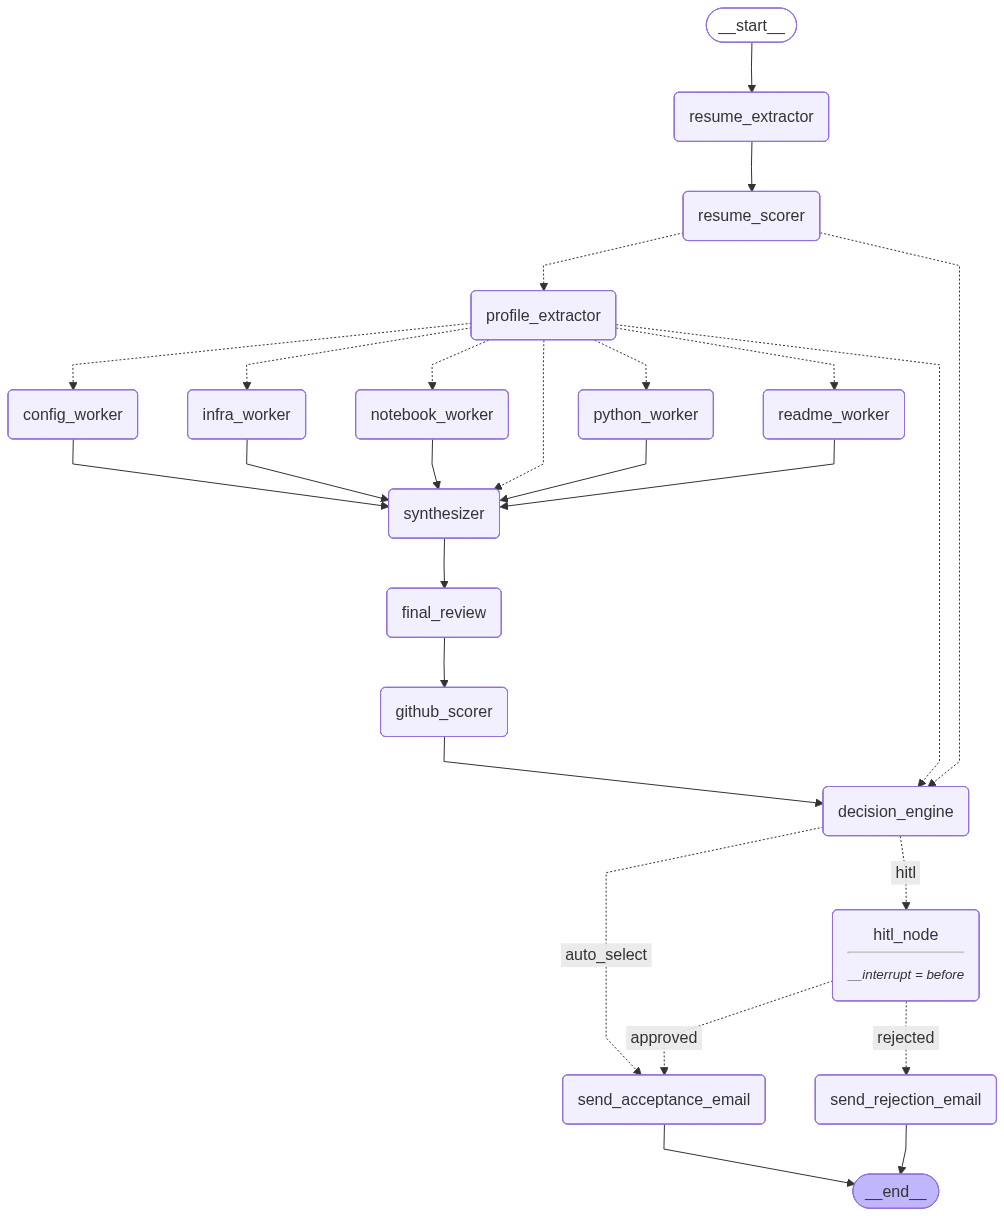

In [45]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:

import uuid
THREAD = str(uuid.uuid4())
JD="""
This Senior AI Engineer role is a hands-on individual contributor position, sitting between Data Science and AI Engineering. You will lead AI proof-of-concepts, design retrieval and context strategies, contribute to the AI architecture, and ensure solutions are robust, scalable and commercially grounded. The role spans the full AI lifecycle, from data preparation and model evaluation through to deployment and optimisation.



Key responsibilities

• Lead development of LLM and AI proof-of-concepts

• Design and implement RAG pipelines and agentic workflows

• Define evaluation frameworks for LLM quality and response accuracy

• Partner with product and engineering on chat flows and continuous improvement

• Contribute to AI platform architecture and best practices

• Mentor junior ML / AI engineers (no formal line management)
"""

result = graph.invoke({
    "job_description":    JD,
    "resume_path":        "./sample_resumes/pdfresume.pdf",
    "role_title":         "",
    "resume_text":        "",          # auto-populated by resume_extractor
    "candidate_name":     "Mouli",
    "candidate_email":    "mouli23@gmail.com",
    "applied_role":         "AI Engineer",
    "github_url":         None,        # auto-populated by resume_extractor
    "linkedin_url":       None,
    "url":                "",
    "routed_files":       [],
    "summaries":          {},
    "next_action":        "",
    "final_summary":      "",
    "final_profile":      "",
    "total_files_found":  0,
    "total_files_analyzed": 0,
    "repos_skipped":      [],
    "analyzed_repos":     [],
    "analysis_coverage":  0.0,
    "security_red_flags": [],
    "resume_score":       0.0,
    "resume_analysis":    "",
    "github_score":       0.0,
    "github_analysis":    "",
    "decision":           "hitl",
    "hitl_outcome":       None,
    "hitl_reason":        None,
    "hitl_packet":        None,
    "rejection_reason":   "",
    "next_steps":         "",
    "email_sent":         False,
}, {"configurable": {"thread_id": THREAD}})

print("Decision :", result.get("decision"))
print("Resume   :", result.get("resume_score"))
print("GitHub   :", result.get("github_score"))

# If decision == "hitl", graph pauses here.
# Check the HR review packet:
print("\\nHR Packet:", result.get("hitl_packet"))




---RESUME EXTRACTOR---
--- RESUME SCORER ---
---PROFILE EXTRACTOR---
  Found 25 original repos (forks excluded)
  Analyzed repos: ['aws_bedrock_projects', 'AWS_BEDROCK_RAG_APP', 'aws_blog_generation', 'Chatbot_with_Groq_llm', 'Chatbot_with_ollama', 'Code_Gen_Eval_Agent', 'Dynamic-Planner-Worker-Pattern-Research-Paper-Writing-Agent', 'HR_AGENT', 'LangChain-Generative-AI-Series', 'Langchain_Converational_RAG_History', 'Langchain_Document_QandA', 'LangGraph-Basic_Chatbot', 'LangGraph-Chatbot_with_web', 'LangGraph_AI_News_Agent', 'langgraph_rag', 'LangGraph_Workflows', 'Multi-LLM-Children-s-Q-A-Chatbot-Groq-OpenAI-Ollama-', 'NotebookLLM_style_RAG_Assistant', 'Prompt_Gen_Eval_Agent', 'Python-project', 'Research_Assistant', 'University_AI_Assistant', 'web_summarizer', 'youtube_summarizer']
  Found 242 relevant files
--- DISPATCH WORKERS (parallel) ---
  Capping python_worker: 181 → 50 files
  → dispatching python_worker (50 files)
  → dispatching readme_worker (20 files)
  → dispatching infr

In [50]:
#IF HITL — RESUME THE GRAPH WITH HR DECISION:

from langgraph.types import Command

final = graph.invoke(
    Command(resume={
        "outcome": "rejected",          # "approved" or "rejected" or "request_more_info"
        "reason":  "mismatch."
    }),
    {"configurable": {"thread_id": THREAD}}   # same thread_id
)

print("Email sent:", final.get("email_sent"))
print("Decision  :", final.get("hitl_outcome"))



--- HITL: Awaiting HR Decision ---

HR REVIEW PACKET
Candidate     : Nagavenkata Chandramouli Etamsetti
Role          : AI Engineer
Resume Score  : 68.0/100
GitHub Score  : 83.0/100
GitHub URL    : https://github.com/Mouli423

Reason for review: GitHub score (83.0/100) is strong but resume score (68.0/100) is below threshold (70). GitHub suggests strong capability — worth reviewing resume carefully.

Resume Analysis:
Candiate Name      : Nagavenkata Chandramouli Etamsetti
Detected Seniority : junior
Score              : 68/100
Seniority Alignment: partial
Domain Alignment   : strong

Matched Skills     : LLM development, RAG pipelines, Agentic workflows, Evaluation frameworks for LLMs, AI platform architecture contributions, Cloud deployment (AWS), Multi‑agent orchestration, Production‑style FastAPI services
Missing Skills     : Mentoring junior engineers, Extensive large‑scale production architecture leadership, Formal technology road‑mapping for AI platforms
Nice-to-Have Found : AWS 